In [117]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
import pandas as pd
from IPython.display import display, Math, clear_output
import matplotlib.pyplot as plt 

from Quantum_Simulation.Floquet import Floquet_Simulation
from Signal_Analysis.SignalAnalysis import Fourier_Transform, Atomic_Norm_Minimization

import json

# 1 Set Connection

In [ ]:
with open("secret.json") as f:
    cfg = json.load(f)

QiskitRuntimeService.save_account(
    token=cfg["TOKEN"],
    instance=cfg["INSTANCE"],
    overwrite=True
)

service = QiskitRuntimeService()

# List accessible real backends
print("Avaiable backends with gates")
backends = service.backends(simulator=False, operational=True)

for b in backends:
    name = b.name
    ops = set(getattr(b.target, "operation_names", []))
    if "cz" in ops:  # crude but useful sign for Heron-style target
        print(name, sorted(list(ops))[:10], "...")


Avaiable backends with gates
ibm_fez ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'] ...
ibm_marrakesh ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'] ...
ibm_torino ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x'] ...


## 1.1 Choice of hardware and Noise characterization

Backend: ibm_fez
Qubits: 156



Metric,Min,Mean,Median,Max
T1 (µs),10.46,144.5,144.7,252.3
T2 (µs),3.789,102.0,100.3,249.0
Readout error,3.66e-03,0.029,0.015,0.458


Gate,Metric,Min,Mean,Median,Max
rz,error,0,0,0,0
rz,duration (ns),0,0,0,0
sx,error,1.21e-04,6.81e-03,2.85e-04,1.000
sx,duration (ns),24.00,24.00,24.00,24.00
x,error,1.21e-04,6.81e-03,2.85e-04,1.000
x,duration (ns),24.00,24.00,24.00,24.00
measure,error,3.66e-03,0.029,0.015,0.458
measure,duration (ns),1560.0,1560.0,1560.0,1560.0
cz,error,1.31e-03,0.027,2.61e-03,1.000
cz,duration (ns),68.00,68.23,68.00,88.00


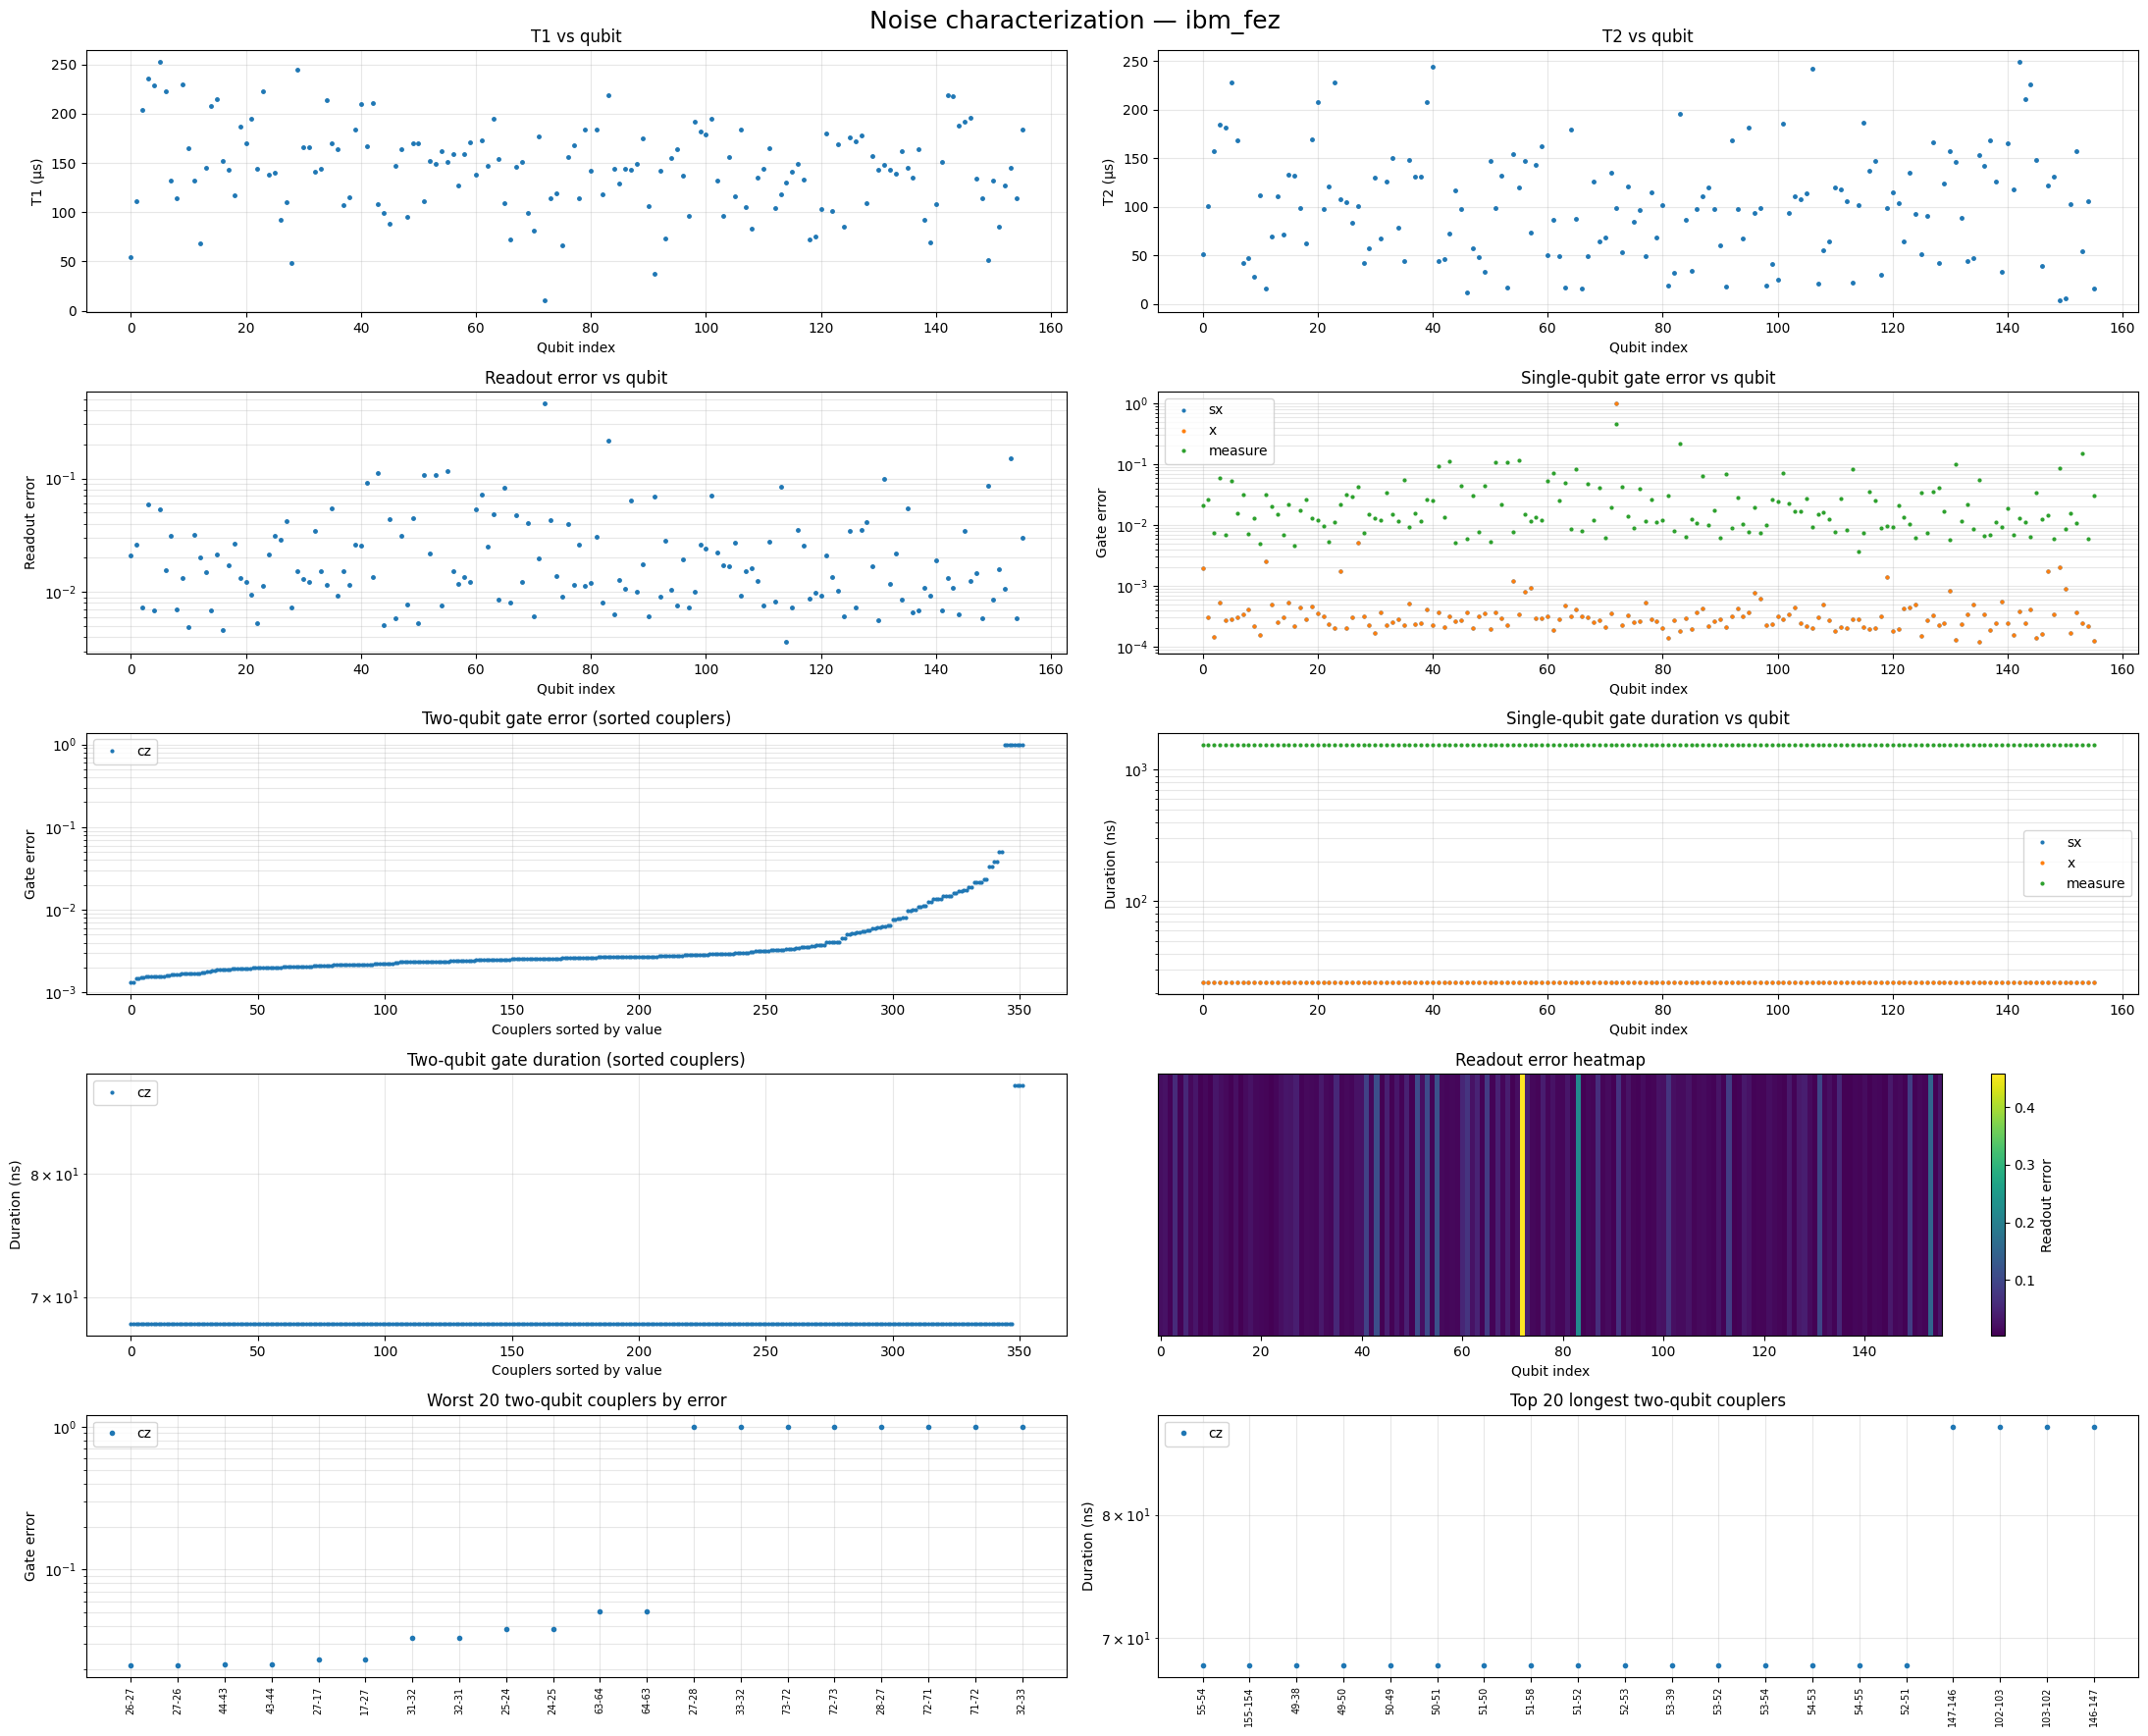

In [ ]:
from utils.NoiseVisualization import BackendNoiseVisualizer

backend = service.backend("ibm_fez") # Choose avaiable processor
viz = BackendNoiseVisualizer(
    backend,
    gate_names=["rz", "sx", "x", "measure", "ecr", "cx", "cz"],
    figsize=(22, 18)
)

viz.print_summary()
print("\n \n ")
viz.plot_dashboard(top_k_couplers=20)

# 2 Two-level system driven by Circular Polarized Field

Given the following hamiltonian 
$$
H(t) = \frac{\omega_0}{2} Z + \Omega \left( X \cos(\omega t) + Y \sin(\omega t) \right)
$$

We can compute analytically the quasienergies
$$
\epsilon_{\pm} =
\frac{\omega}{2}
\pm
\sqrt{
\left(\frac{\omega}{2}-\frac{\omega_0}{2}\right)^2
+
\left(\frac{\Omega}{2}\right)^2
}
$$

The latter are defined $\mathrm{mod}\,\omega$, choosing 
$\epsilon_{\pm} \in \left[-\frac{\omega}{2},\,\frac{\omega}{2}\right]$, 
we see that 
$\epsilon_- = -\epsilon_+ \; (\mathrm{mod}\,\omega)$.

We define $h_1 := \frac{\omega _0}{2}, \; h_2:= \Omega$, while T is the period of the Hamiltonian

In this section we choose $h_1 = 1, \; h_2 = \sqrt{2}, \; T = 1$

## 2.1 Analytical distribution

Quasienergies computed analytically:


<IPython.core.display.Math object>

Period probability distribution: 10.923656334979848


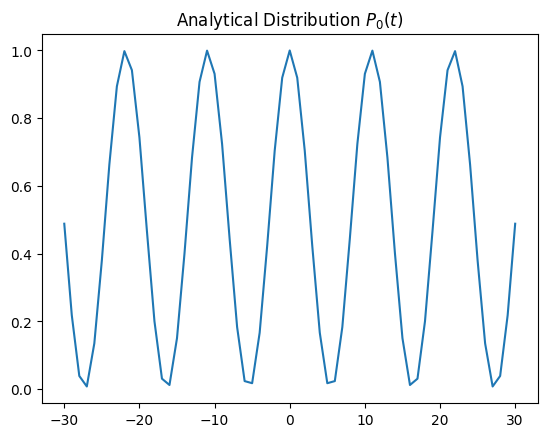

In [ ]:
h1, h2, T = 1, np.sqrt(2), 1
num_points = 60
# Probability distribution generated for t in [- num_points * T, num_points * T] with spacing dt = T

FS_noisless = Floquet_Simulation(T=T, parameters=[h1, h2])
epsilon = FS_noisless.quasi_energy_circular()

print("Quasienergies computed analytically:")
display(Math(r"\epsilon_{\pm} = \pm %.5f" % (epsilon)))
print(f"Period probability distribution: {2 * np.pi / epsilon}")

plt.title(f"Analytical Distribution $P_0(t)$")
t = T * np.arange(-int(num_points / 2), int(num_points / 2) + 1, 1)
P_analytical = (1 + np.cos(epsilon * t)) / 2
plt.plot(t, P_analytical)
plt.show()

### 2.1.1 Study of the reconstruction error with DFT and ANM

Given the analytical probability distribution
$$P_0(t)= \frac{1}{2} (1 + cos(\epsilon t))$$

with $\epsilon \approx 0.57519 $

We generate the analytical distribution in a given time window then use DFT and ANM to recover $\epsilon$.
For varying rent time windows we can compute the reconstruction error  
$$\frac{|\epsilon_{reconstructed} - \epsilon }{\epsilon}|$$.

The goal is to identify the minimum time window for which DFT and ANM achieves a reconstruction with an error less than 10%.

In [99]:
np.arange(1, 10 + 2, 2),
max(1, 2)

2

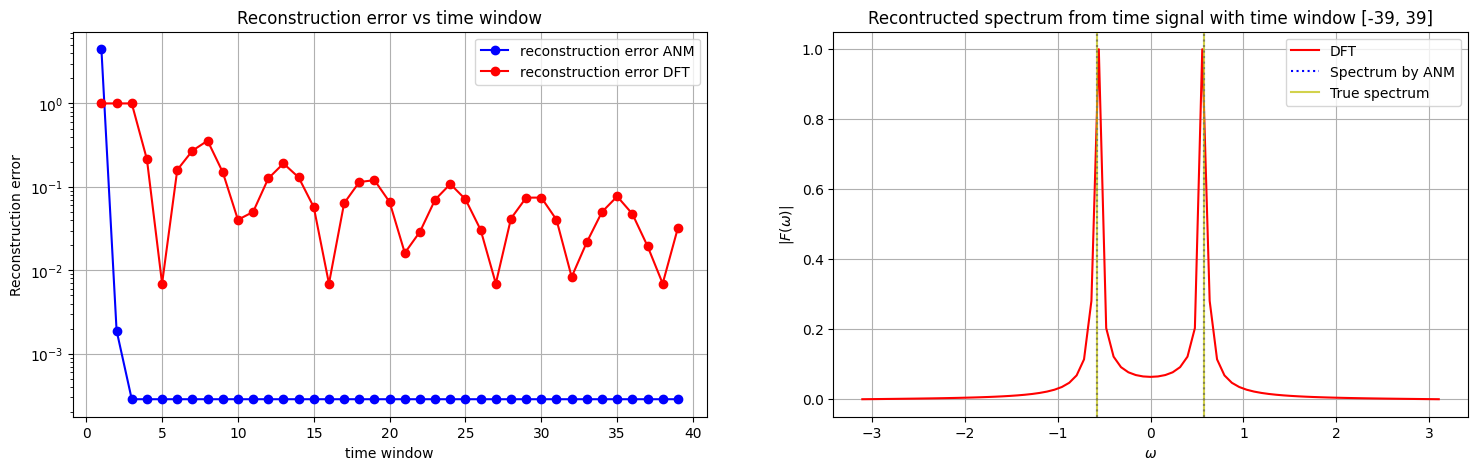

In [111]:
# Here reconstruction error is studied with time window varying from [-T, T] to [-T * max_time_window, T * max_time_window]
# In the plot on the left reconstruction error is showed vs time window, 
# while on the right spectrum reconstructed for that given time window

max_time_window = 40    # Max Time window to choose
step_size_time_window = 1 # Increment per loop

error_list_DFT = []
error_list_ANM = []
times = np.arange(1, min(max_time_window, max_time_window + step_size_time_window), step_size_time_window) * T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
for i, time_window in enumerate(times):
    t = np.arange(-time_window, time_window + step_size_time_window)
    P_analytical = (1 + np.cos(epsilon * t)) / 2
    DFT, ANM = Fourier_Transform(t, P_analytical - 1/2), Atomic_Norm_Minimization(t, P_analytical)
    epsilon_ANM  = np.abs(ANM.get_spectrum(-np.pi, np.pi, lam=0., plot=False, threshold=0.05, w_exp=[epsilon], num_nu=5000)[0])
    error_list_ANM.append(np.abs(epsilon - epsilon_ANM) / epsilon)
    result_DTF = DFT.get_DFT(plot=False)
    epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
    error_list_DFT.append(np.abs(epsilon - epsilon_DFT) / epsilon)


    ax1.clear()
    ax2.clear()

    ax1.plot(times[:i + 1], error_list_ANM, 'bo-', label="reconstruction error ANM")
    ax1.plot(times[:i + 1], error_list_DFT, 'ro-', label="reconstruction error DFT")
    ax1.set_yscale('log')
    ax1.set_xlabel("time window")
    ax1.set_ylabel("Reconstruction error")
    ax1.set_title("Reconstruction error vs time window")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(result_DTF[0], result_DTF[1], 'r', label="DFT")
    ax2.set_xlabel('$\omega$')
    ax2.set_ylabel('$|F(\omega)|$')
    ax2.set_title(f"Recontructed spectrum from time signal with time window [{-time_window}, {time_window}]")
    ax2.axvline(x=epsilon_ANM, color = 'b', ls = ":", label="Spectrum by ANM")
    ax2.axvline(x=-epsilon_ANM, color = 'b', ls = ":")
    ax2.axvline(x=epsilon, color = 'y', ls = "-", alpha=0.7, label="True spectrum")
    ax2.axvline(x=-epsilon, color = 'y', ls = "-", alpha=0.7)
    ax2.grid(True)
    ax2.legend()

    clear_output(wait=True)
    plt.pause(0.5)
    display(fig)

plt.close(fig)


We see that ANM achieves a good reconstruction error (0.02) with time window [-2, 2], going beyond the Fourier limit, as $2 < \frac{\pi}{\epsilon} \approx 5 $.

For [-3, 3] ANM converge towards an error of $3 \times 10^{-4}$.
DFT error decreased with an oscillatory behaviour and to oscillate around $10^{-4}$ it needs a time window of about 2000.(See next cell)

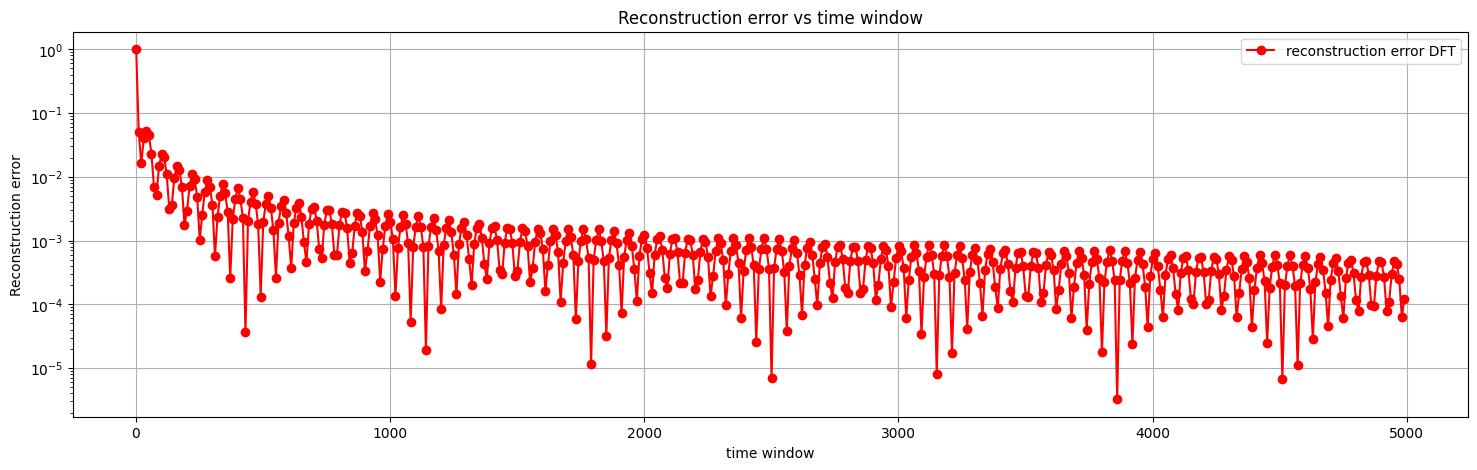

In [110]:
# Static plot Reconstruction error vs time window for DFT

max_time_window = 5000    # Max Time window to choose
step_size_time_window = 10  # Increment per loop

error_list_DFT = []
times = np.arange(1, min(max_time_window, max_time_window + step_size_time_window), step_size_time_window) * T

fig, ax1 = plt.subplots(figsize=(18, 5))
for i, time_window in enumerate(times):
    t = np.arange(-time_window, time_window + 1)
    P_analytical = (1 + np.cos(epsilon * t)) / 2
    DFT, ANM = Fourier_Transform(t, P_analytical - 1/2), Atomic_Norm_Minimization(t, P_analytical)
    result_DTF = DFT.get_DFT(plot=False)
    epsilon_DFT = np.abs(result_DTF[0][np.argmax(result_DTF[1])])
    error_list_DFT.append(np.abs(epsilon - epsilon_DFT) / epsilon)


    ax1.clear()

    ax1.plot(times[:i + 1], error_list_DFT, 'ro-', label="reconstruction error DFT")
    ax1.set_yscale('log')
    ax1.set_xlabel("time window")
    ax1.set_ylabel("Reconstruction error")
    ax1.set_title("Reconstruction error vs time window")
    ax1.legend()
    ax1.grid(True)

    clear_output(wait=True)
    display(fig)

plt.close(fig)


In conclusion the minimum time window to achieve an error less than $10\%$  for ANM is $[-2, 2]$ with error 0.002 

while for DFT is $[-5, 5]$ with error $0.006$